# Lesson 1: Single Systems

Built from tutorial: https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/qiskit-implementation

In [19]:
from numpy import sqrt
from qiskit.quantum_info import Statevector

In [20]:
u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

display(u.draw("text"))
display(u.draw("latex"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

$w$ is not a valid state vector since it has a norm < 1.

In [21]:

print(u.is_valid())
print(w.is_valid())

True
False


In [22]:
outcome, state = v.measure()
print(f"Measured: {outcome}\n Post-measurement state:")
display(state.draw("latex"))

Measured: 0
 Post-measurement state:


<IPython.core.display.Latex object>

Since the state vector $v$ specifies the first outcome $\left(\frac{1+2i}{\sqrt(5)}\right) |0\rangle$ is 0.555 and $-|1\rangle$ as 0.444, we expect a distribution to agree with these probabilities. As *count* increases, the distribution approaches the probabilities listed before (law of large numbers). 

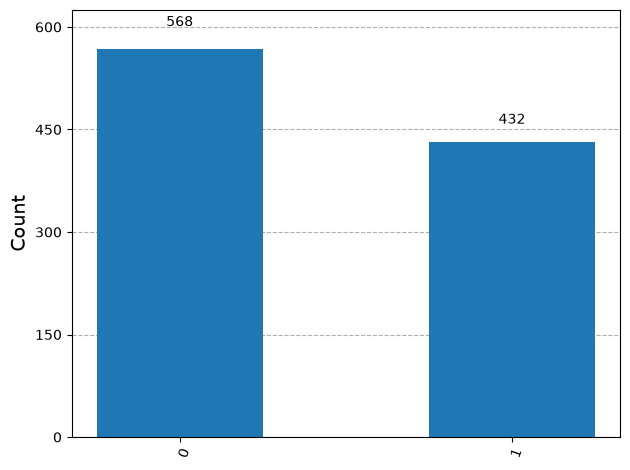

In [23]:
from qiskit.visualization import plot_histogram

count = 1000

statistics = v.sample_counts(count)
plot_histogram(statistics)

In [24]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

x = Statevector([1, 0])

x = x.evolve(H)
x = x.evolve(T)
x = x.evolve(H)
x = x.evolve(S)
x = x.evolve(Y)

display(x.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can create a *quantum circuit*, which in this case is just a sequence of unitary operators (complex matrix operators with columns of norm 1).

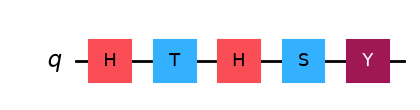

<IPython.core.display.Latex object>

In [25]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

display(Operator.from_circuit(circuit).draw("latex"))

We can also apply the quantum circuit to a state vector (such as $|0\rangle$).

In [26]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

We can simulate experiments where a fresh copy of the state $|0\rangle$ is measured with a standard basis measurement.

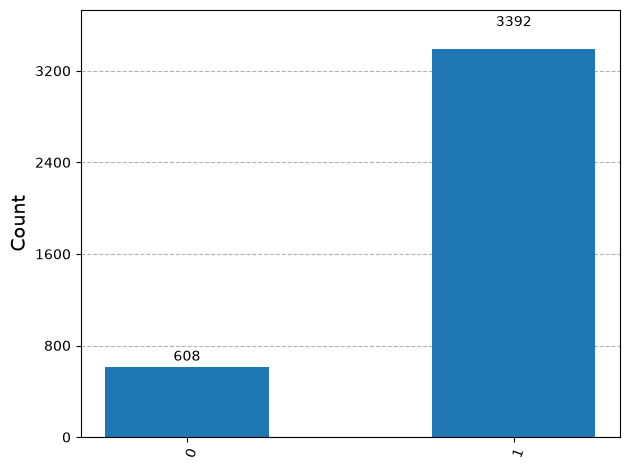

In [27]:
measurements = v.sample_counts(4000)
display(plot_histogram(measurements))